In [1]:
import sys
sys.path.append('C:/Users/ryansenne/PycharmProjects/dCA1_Paper')

import onep
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pickle

## Load data and whatnot

In [2]:
ddir = r"C:\Users\ryansenne\Desktop\Dill\hab_traces_csv"
files = [f for f in os.listdir(ddir) if f.endswith("hab_accepted_traces.csv")]

# load files
named_dfs = {}
for f in files:
    animal_id = f.split("_hab_accepted_traces.csv")[0]
    df = pd.read_csv(os.path.join(ddir, f), index_col=0)
    named_dfs[animal_id] = df

named_dfs

{'astroF10':               C001      C002      C004      C006      C007      C008  \
  C000                                                                  
 0.109999  0.031965 -0.000913  0.022610  0.026684  0.031286  0.056453   
 0.076046  0.027265 -0.001218  0.017070  0.021927  0.023895  0.041990   
 0.066145  0.032060 -0.000810  0.013455  0.026366  0.026060  0.038708   
 0.060940  0.043174 -0.001416  0.011842  0.030439  0.029148  0.040708   
 0.056507  0.053177 -0.002293  0.010797  0.034813  0.029548  0.046975   
 ...            ...       ...       ...       ...       ...       ...   
 0.004479  0.002083  0.001770  0.008656  0.002065  0.000931  0.000969   
 0.004642  0.001623  0.000659  0.009922 -0.000565  0.002382 -0.000018   
 0.004623  0.001243  0.000128  0.009170 -0.000071  0.001970  0.001435   
 0.005853  0.002010  0.001267  0.008324  0.000218  0.001102  0.002610   
 0.003448  0.001203  0.001004  0.008893  0.000932  0.000970  0.002275   
 
               C009      C010      C0

## Rep traces

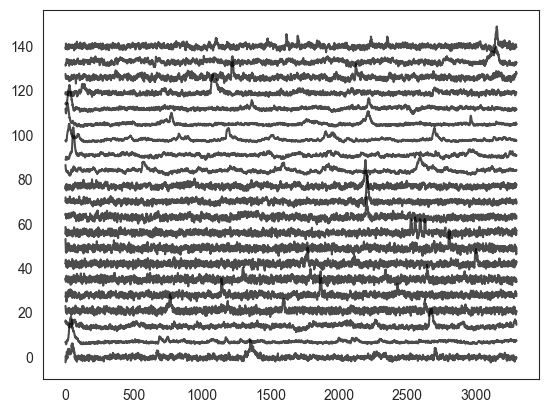

In [3]:

traces_to_plot = np.zeros((21, 3300))
i = 0
for _, df in named_dfs.items():
    df_transposed = df.T
    # grab two random traces from each animal
    sampled_traces = df_transposed.sample(n=3).to_numpy()
    traces_to_plot[i:i+3, :] = sampled_traces[:, :3300]
    i += 3

# z-score each trace
traces_to_plot = stats.zscore(traces_to_plot, axis=1)

# plot a ridghe plot like the others
plt.figure()
sns.set_style("white")
for i, trace in enumerate(traces_to_plot):
    plt.plot(trace + i * 7, color='black', alpha=0.7)  # Offset each trace for visibility


plt.savefig(r"C:\Users\ryansenne\Desktop\Dill\hab_traces_ridgeplot.svg", dpi=300)

In [8]:
# Stat test for # events across sessions

hab_events = [0, 0, 1, 1, 1, 2, 3]
cxt_a = [2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 4, 5]
cxt_b = [1, 1, 1, 2, 2, 2, 3, 4, 3, 3, 4]

stats.kruskal(hab_events, cxt_a, cxt_b)

pairs = [
    mannwhitneyu(hab_events, cxt_a, alternative="two-sided").pvalue,
    mannwhitneyu(hab_events, cxt_b, alternative="two-sided").pvalue,
    mannwhitneyu(cxt_a, cxt_b, alternative="two-sided").pvalue,
]

multipletests(pairs, method="holm")


# # make plot of this data
# plt.figure(figsize=(3, 4))
# data = pd.DataFrame({
#     "num_events": hab_events + cxt_a + cxt_b,
#     "session": ["hab"] * len(hab_events) + ["cxt_a"] * len(cxt_a) + ["cxt_b"] * len(cxt_b)
# })
# sns.boxplot(x="session", y="num_events", data=data, palette="Set2")
# sns.swarmplot(x="session", y="num_events", data=data, color=".25")
# plt.ylabel("Number of Detected Events")

# plt.savefig(r"C:\Users\ryansenne\Desktop\Dill\num_events_hab_cxt.svg", dpi=300)

(array([ True, False, False]),
 array([0.0224532 , 0.08947569, 0.45789238]),
 0.016952427508441503,
 0.016666666666666666)

## Run shuffle correlations

In [43]:
def run_cross_validated_analysis(
    animal_id,
    traces,
    timestamps,
    save_path_prefix,
    event_times,                
    window=28,                   
    do_shuffle=True,
    n_shuffles=10000,
    seed=None,
    two_sided=True
):
    """
    Compute cross-validated sequence correlation between two interleaved sets of events
    (odd vs. even indices of `event_times`) for astrocyte traces.

    Parameters
    ----------
    event_times : array-like
        Absolute or relative event times (seconds). Odd = 1st,3rd,5th,... ; Even = 2nd,4th,6th,...
    window : float
        ETA window length in seconds
    """
    def shuffle_control_test(x, y, n_shuffles=1000, seed=None, two_sided=True):
        x = np.asarray(x); y = np.asarray(y)
        if x.shape[0] != y.shape[0]:
            raise ValueError(f"Length mismatch: x={x.shape[0]}, y={y.shape[0]}")
        if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
            raise ValueError("Non-finite values in x or y")
        rng = np.random.default_rng(seed)
        r_obs, p_obs = stats.spearmanr(x, y)
        sh = np.empty(n_shuffles, dtype=float)
        for i in range(n_shuffles):
            y_perm = rng.permutation(y)
            sh[i], _ = stats.spearmanr(x, y_perm)
        if two_sided:
            p_emp = (np.sum(np.abs(sh) >= abs(r_obs)) + 1) / (n_shuffles + 1)
        else:
            if r_obs >= 0:
                p_emp = (np.sum(sh >= r_obs) + 1) / (n_shuffles + 1)
            else:
                p_emp = (np.sum(sh <= r_obs) + 1) / (n_shuffles + 1)
        return {
            "r_obs": float(r_obs),
            "p_obs_parametric": float(p_obs),
            "shuffle_rhos": sh,
            "p_empirical": float(p_emp),
            "null_mean": float(np.mean(sh)),
            "null_std": float(np.std(sh, ddof=1)),
            "z_obs_vs_null": float((r_obs - np.mean(sh)) / (np.std(sh, ddof=1) + 1e-12)),
        }

    def plot_shuffle_null(shuffle_rhos, r_obs, figsize=(3.5, 3.5), dpi=600):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.hist(shuffle_rhos, bins=30, density=True)
        ax.axvline(r_obs, linestyle='--')
        ax.set_xlabel('Spearman ρ')
        ax.set_ylabel('Density')
        ax.set_title('Shuffle null (permute Y across cells)')
        return fig, ax

    # ---------------- analysis ----------------
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})

    # ---- Parse and split events into odd/even ----
    event_times = np.asarray(event_times, dtype=float)
    if event_times.ndim != 1 or event_times.size < 2:
        raise ValueError("`event_times` must be a 1D array with at least two times.")

    odd_times  = event_times[0::2].tolist()
    even_times = event_times[1::2].tolist()
    if len(odd_times) == 0 or len(even_times) == 0:
        raise ValueError("Need at least one odd and one even event time.")

    # ---- Compute ETAs for odd and even events ----
    # onep.eta_individual_cells expects a list-of-lists (per your original [[120, 240]] usage),
    # so we wrap the times in a list.
    whole_eta_odd,  time_vec_odd  = onep.eta_individual_cells(traces.T, timestamps, [odd_times],  window=window)
    whole_eta_even, time_vec_even = onep.eta_individual_cells(traces.T, timestamps, [even_times], window=window)

    # ---- Align to time >= 0 (replaces magic index 140) ----
    # We assume time vectors are identical for odd/even; use odd as reference.
    t0_idx = int(np.searchsorted(time_vec_odd, 0.0, side="left"))
    if t0_idx <= 0 or t0_idx >= len(time_vec_odd):
        # Fallback: if 0 isn't inside the window, keep everything (rare, but safer than crashing)
        t0_idx = 0
    time_post0 = time_vec_odd[t0_idx:]

    # ---- Z-score each cell using only the post-0 segment, like your original ----
    adjusted_odd  = stats.zscore(whole_eta_odd[:,  t0_idx:], axis=1)
    adjusted_even = stats.zscore(whole_eta_even[:, t0_idx:], axis=1)

    # ---- Sort arrays by their own maxima ----
    sorted_odd,  idxs_odd  = onep.maxsort(adjusted_odd)
    sorted_even, idxs_even = onep.maxsort(adjusted_even)

    # y-ticks for heatmaps
    first_last = [0, adjusted_odd.shape[0]]

    # --- Heatmaps ---
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(7, 5), dpi=600)
    sns.set(style="ticks", font="Arial")

    # Left: odd, sorted by odd
    sns.heatmap(adjusted_odd[idxs_odd], ax=ax1, cmap='mako', cbar=False,
                xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.set_xticks(np.linspace(0, len(time_post0), 5))
    ax1.set_xticklabels(np.linspace(np.min(time_post0), np.max(time_post0), 5).astype(int), rotation=0)
    ax1.set_yticks(first_last)
    ax1.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax1.set_title('Odd events (sorted by Odd)', fontsize=10, pad=10)
    ax1.set_ylabel('Astrocyte #', fontsize=10)
    ax1.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax1, left=True, bottom=True)

    # Right: odd, sorted by even (cross-sorting)
    # FIX: use adjusted_even's sort order (idxs_even) to reorder the odd matrix.
    sns.heatmap(adjusted_odd[idxs_even], ax=ax2, cmap='mako', cbar=True,
                cbar_kws={'label': 'Z-score'}, xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax2.tick_params(axis='both', which='major', labelsize=8)
    ax2.set_xticks(np.linspace(0, len(time_post0), 5))
    ax2.set_xticklabels(np.linspace(np.min(time_post0), np.max(time_post0), 5).astype(int), rotation=0)
    ax2.set_yticks(first_last)
    ax2.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax2.set_title('Odd events (sorted by Even)', fontsize=10, pad=10)
    ax2.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax2, left=True, bottom=True)

    plt.tight_layout(pad=3)
    heatmap_fp = f"{save_path_prefix}_heatmaps.svg"
    fig.savefig(heatmap_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # --- Argmaxes ---
    max_idxs_odd = np.argmax(sorted_odd, axis=1)
    argmax_odd = time_post0[max_idxs_odd]

    odd_sorted_by_even = adjusted_odd[idxs_even]
    sorted_idx = np.argmax(odd_sorted_by_even, axis=1)
    argmax_odd_sorted_by_even = time_post0[sorted_idx]

    # --- Spearman correlation ---
    rho_s, p_s = stats.spearmanr(argmax_odd, argmax_odd_sorted_by_even)
    print(f"{animal_id} - Spearman rho: {rho_s:.4f}, p-value: {p_s:.4e}")

    # --- Shuffle control (optional) ---
    shuffle_fp = None
    shuffle_empirical_p = None
    shuffle_null_mean = None
    shuffle_null_std = None
    z_obs_vs_null = None

    if do_shuffle:
        if seed is None:
            seed = hash(str(animal_id)) & 0xFFFFFFFF
        shres = shuffle_control_test(
            argmax_odd, argmax_odd_sorted_by_even,
            n_shuffles=n_shuffles, seed=seed, two_sided=two_sided
        )
        print(f"{animal_id} - shuffle null: mean={shres['null_mean']:.4f}, "
              f"sd={shres['null_std']:.4f}, empirical p={shres['p_empirical']:.4g}, "
              f"z={shres['z_obs_vs_null']:.2f}")
        fig_shuf, ax_shuf = plot_shuffle_null(shres["shuffle_rhos"], shres["r_obs"])
        shuffle_fp = f"{save_path_prefix}_shuffle_null.svg"
        fig_shuf.savefig(shuffle_fp, dpi=600, bbox_inches='tight')
        plt.close(fig_shuf)

        shuffle_empirical_p = shres["p_empirical"]
        shuffle_null_mean = shres["null_mean"]
        shuffle_null_std = shres["null_std"]
        z_obs_vs_null = shres["z_obs_vs_null"]

    # --- Regression data (clean) ---
    df = pd.DataFrame({
        'Argmax Odd sorted Odd':  argmax_odd,
        'Argmax Odd sorted Even': argmax_odd_sorted_by_even
    })
    x_name = 'Argmax Odd sorted Odd'
    y_name = 'Argmax Odd sorted Even'
    _df = df[[x_name, y_name]].copy()
    _df = _df[np.isfinite(_df[x_name]) & np.isfinite(_df[y_name])]
    x = _df[x_name].to_numpy()
    y = _df[y_name].to_numpy()
    X = sm.add_constant(x)

    # --- Fit RLM ---
    model = sm.RLM(y, X).fit()

    # ---- R^2 variants ----
    y_pred = np.asarray(model.fittedvalues)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_var = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # guard for degenerate correlation
    try:
        r2_corr = float(np.corrcoef(y, y_pred)[0, 1] ** 2)
    except Exception:
        r2_corr = np.nan

    rho_rlm = model.model.M.rho
    scale = getattr(model, "scale", 1.0) or 1.0
    resid_fit_scaled = (y - y_pred) / scale
    resid_null_scaled = (y - float(np.mean(y))) / scale
    loss_fit = float(np.sum(rho_rlm(resid_fit_scaled)))
    loss_null = float(np.sum(rho_rlm(resid_null_scaled)))
    r2_pseudo_robust = 1 - (loss_fit / loss_null) if loss_null > 0 else np.nan

    # ---- Extract flattened params ----
    beta  = np.asarray(model.params)        # [intercept, slope]
    pvals = np.asarray(model.pvalues)       # [p_intercept, p_slope]
    intercept = float(beta[0]) if beta.size > 0 else np.nan
    slope     = float(beta[1]) if beta.size > 1 else np.nan
    p_value_bias  = float(pvals[0]) if pvals.size > 0 else np.nan
    p_value_slope = float(pvals[1]) if pvals.size > 1 else np.nan

    # --- Plot: scatter + RLM line + 95% CI (bootstrap with fallback) ---
    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set(style="ticks", font="Arial")
    sns.scatterplot(data=_df, x=x_name, y=y_name, color='#231f20', ax=ax)

    x_grid = np.linspace(x.min(), x.max(), 200)
    X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
    y_hat = X_grid @ np.asarray(model.params)
    ax.plot(x_grid, y_hat, color='#231f20', lw=2, label='RLM fit')

    n_boot = 1000
    min_ok = 100
    rng = np.random.default_rng(12345)
    y_boot = np.full((n_boot, x_grid.size), np.nan, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, len(_df), size=len(_df))
        xb = x[idx]; yb = y[idx]
        Xb = sm.add_constant(xb)
        try:
            mb = sm.RLM(yb, Xb).fit()
            y_boot[b, :] = X_grid @ np.asarray(mb.params)
        except Exception:
            pass

    counts = np.sum(np.isfinite(y_boot), axis=0)
    lower = np.full_like(y_hat, np.nan)
    upper = np.full_like(y_hat, np.nan)
    ok = counts >= min_ok
    if np.any(ok):
        lower[ok] = np.nanpercentile(y_boot[:, ok], 2.5, axis=0)
        upper[ok] = np.nanpercentile(y_boot[:, ok], 97.5, axis=0)

    if np.any(~ok):
        covb = np.asarray(model.cov_params())
        se_mean = np.sqrt(np.sum(X_grid @ covb * X_grid, axis=1))
        z = stats.norm.ppf(0.975)
        lower_analytic = y_hat - z * se_mean
        upper_analytic = y_hat + z * se_mean
        lower[~ok] = lower_analytic[~ok]
        upper[~ok] = upper_analytic[~ok]

    ax.fill_between(x_grid, lower, upper, alpha=0.2, label='95% CI')
    ax.set_xlabel('Argmax Odd Sorted Odd (s)', fontsize=10, fontname="Arial")
    ax.set_ylabel('Argmax Odd Sorted Even (s)', fontsize=10, fontname='Arial')
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, window)   # keep your 0–25 style if window=28; adjust as you like
    ax.set_xlim(0, window)
    sns.despine(ax=ax)
    ax.legend(frameon=False)

    scatter_fp = f"{save_path_prefix}_scatter.svg"
    fig.savefig(scatter_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # ---- Return flattened summary ----
    return {
        "animal": animal_id,
        "spearman_rho": float(rho_s),
        "spearman_p": float(p_s),
        "slope": slope,
        "intercept": intercept,
        "p_value_slope": p_value_slope,
        "p_value_bias": p_value_bias,
        "r2_var": float(r2_var),
        "r2_corr": float(r2_corr) if np.isfinite(r2_corr) else np.nan,
        "r2_pseudo_robust": float(r2_pseudo_robust) if np.isfinite(r2_pseudo_robust) else np.nan,
        "heatmap_fp": heatmap_fp,
        "scatter_fp": scatter_fp,
        "shuffle_hist_fp": shuffle_fp,
        "shuffle_empirical_p": shuffle_empirical_p,
        "shuffle_null_mean": shuffle_null_mean,
        "shuffle_null_std": shuffle_null_std,
        "shuffle_z": z_obs_vs_null,
    }


In [46]:
# Load the pickle file
with open('/Users/ryansenne/Desktop/Dill/collection_hab_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

# Define animals for each group
mouse_ids = ['astroF9', 'astroM10']

#Grab your mice and take accepted traces - convert to numpy arrays within mouse_id variable names
for mouse_id in mouse_ids:
    try:
        traces = collection_fc.animals[mouse_id].accepted_traces.to_numpy()
        globals()[mouse_id] = traces[:3303, :]
        print(f"Created variable {mouse_id} with shape {globals()[mouse_id].shape}")
    except Exception as e:
        print(f"Error loading {mouse_id}: {e}")

Created variable astroF9 with shape (3303, 161)
Created variable astroM10 with shape (3303, 52)


In [47]:
event_times_csv = r"C:\Users\ryansenne\Desktop\Dill\hab_traces_csv\event_times.csv"
event_times_df = pd.read_csv(event_times_csv)

# Normalize headers (strip spaces) and build column->times mapping
event_times_df.rename(columns={c: c.strip() for c in event_times_df.columns}, inplace=True)

col_to_times = {}
for col in event_times_df.columns:
    s = pd.to_numeric(event_times_df[col], errors='coerce')  # blank cells -> NaN
    times = s.dropna().astype(float).to_numpy()
    # sort & de-duplicate (keep chronological order if CSV already sorted)
    times = np.unique(np.round(times, 9))  # rounding to avoid fp dupes like 10 vs 9.999999999
    col_to_times[col] = times

def pick_column_for_mouse(mouse_id, candidates):
    """
    Choose the best matching column for a mouse_id.
    Priority: startswith(mouse_id) AND contains '_hab' > startswith(mouse_id) > contains(mouse_id)
    """
    lid = mouse_id.lower()
    # tier 1: startswith + contains _hab
    t1 = [c for c in candidates if c.lower().startswith(lid) and '_hab' in c.lower()]
    if t1: return t1[0]
    # tier 2: startswith
    t2 = [c for c in candidates if c.lower().startswith(lid)]
    if t2: return t2[0]
    # tier 3: contains
    t3 = [c for c in candidates if lid in c.lower()]
    if t3: return t3[0]
    return None


In [49]:
save_dir = '/Users/ryansenne/Downloads'
os.makedirs(save_dir, exist_ok=True)

trace_lookup = {mouse: globals()[mouse] for mouse in mouse_ids}
all_cols = list(col_to_times.keys())

all_results = []
skipped = []

for mouse in mouse_ids:
    print(f"Processing {mouse}...")

    # 1) traces (time x cells)
    traces = trace_lookup.get(mouse, None)
    if traces is None:
        print(f"  [WARN] No traces for {mouse}. Skipping.")
        skipped.append((mouse, "no_traces"))
        continue

    # 2) timestamps (trimmed to match your 3303 rows)
    try:
        # You used capital 'T' earlier
        timestamps = np.asarray(collection_fc.animals[mouse].Timestamps[:traces.shape[0]], dtype=float).ravel()
    except Exception as e:
        print(f"  [WARN] No timestamps for {mouse}: {e}. Skipping.")
        skipped.append((mouse, "no_timestamps"))
        continue

    # sanity align (in case lengths drift)
    T = min(traces.shape[0], timestamps.shape[0])
    traces = traces[:T, :]
    timestamps = timestamps[:T]

    # 3) find the CSV column that belongs to this mouse
    # prefer exact "<mouse>_cxta" if present; else use your matcher
    exact_col = f"{mouse}_cxta"
    if exact_col in col_to_times:
        col = exact_col
    else:
        col = pick_column_for_mouse(mouse, all_cols)

    if col is None:
        print(f"  [WARN] No CSV column matched {mouse}. Skipping.")
        skipped.append((mouse, "no_column"))
        continue

    # 4) load & clip event times to the session range
    ev_all = np.asarray(col_to_times[col], dtype=float)
    tmin, tmax = float(np.nanmin(timestamps)), float(np.nanmax(timestamps))
    ev = ev_all[(ev_all >= tmin) & (ev_all <= tmax)]

    # need at least 2 events (so we have odd/even)
    if ev.size < 2:
        print(f"  [WARN] {mouse}: only {ev.size} event(s) in [{tmin:.2f}, {tmax:.2f}] (col={col}). Skipping.")
        skipped.append((mouse, "too_few_events"))
        continue

    # 5) run analysis (odd vs even handled inside)
    try:
        res = run_cross_validated_analysis(
            animal_id=mouse,
            traces=traces,                 # (time x cells); function uses traces.T internally
            timestamps=timestamps,         # 1D seconds
            save_path_prefix=f"{save_dir}/FC_crossvalled_{mouse}",
            event_times=ev,                # <<< key addition
            window=28,
            do_shuffle=True,
            n_shuffles=10000,
            seed=None,
            two_sided=True
        )
        all_results.append(res)
        print(f"  [OK] rho={res['spearman_rho']:.3f}, p={res['spearman_p']:.3g}, n_events={ev.size}")
    except Exception as e:
        print(f"  [ERROR] {mouse}: {e}")
        skipped.append((mouse, "exception"))

# 6) summarize
df_all_results = pd.DataFrame(all_results)
if 'animal' in df_all_results.columns:
    df_all_results = df_all_results[['animal'] + [c for c in df_all_results.columns if c != 'animal']]

print(df_all_results)
out_csv = f'{save_dir}/crossval_summary_results_cxta.csv'
df_all_results.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
if skipped:
    print("Skipped:", skipped)


Processing astroF9...
astroF9 - Spearman rho: 0.2258, p-value: 3.9808e-03
astroF9 - shuffle null: mean=0.0004, sd=0.0796, empirical p=0.0046, z=2.83
  [OK] rho=0.226, p=0.00398, n_events=3
Processing astroM10...
astroM10 - Spearman rho: -0.2006, p-value: 1.5397e-01
astroM10 - shuffle null: mean=-0.0009, sd=0.1388, empirical p=0.1486, z=-1.44
  [OK] rho=-0.201, p=0.154, n_events=3
     animal  spearman_rho  spearman_p     slope  intercept  p_value_slope  \
0   astroF9      0.225772    0.003981  0.245784   7.708425       0.001887   
1  astroM10     -0.200564    0.153966 -0.153599   8.839327       0.187244   

   p_value_bias    r2_var   r2_corr  r2_pseudo_robust  \
0  2.731585e-12  0.021594  0.031883          0.052744   
1  5.183408e-11  0.012988  0.045251          0.055129   

                                          heatmap_fp  \
0  /Users/ryansenne/Downloads/FC_crossvalled_astr...   
1  /Users/ryansenne/Downloads/FC_crossvalled_astr...   

                                          sc